### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [1]:
!pip install pandas sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.1 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 5.5 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [gre


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [2]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [3]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="536883"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [4]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="536883"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df


Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [5]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [6]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [8]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [10]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [5]:
#YOUR CODE

# 1. Loading tables from SRC
s1_products_df = pd.read_sql("SELECT * FROM s1.s1_products", src_engine)
s1_sales_df = pd.read_sql("SELECT * FROM s1.s1_sales", src_engine)
s2_channels_df = pd.read_sql("SELECT * FROM s2.s2_channels", src_engine)
s2_client_sales_df = pd.read_sql("SELECT * FROM s2.s2_client_sales", src_engine)
s2_clients_df = pd.read_sql("SELECT * FROM s2.s2_clients", src_engine)
s2_locations_df = pd.read_sql("SELECT * FROM s2.s2_locations", src_engine)

# 2. Loading tables from LND
lnd_s1_products_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_products", trg_engine)
lnd_s1_sales_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_sales", trg_engine)
lnd_s2_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_channels", trg_engine)
lnd_s2_client_sales_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_client_sales", trg_engine)
lnd_s2_clients_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_clients", trg_engine)
lnd_s2_locations_df = pd.read_sql("SELECT * FROM lnd.lnd_s2_locations", trg_engine)


def reconcile_tables(src_df, trg_df, table_name, key_columns, compare_columns):
    merged_df = src_df.merge(
        trg_df,
        on=key_columns,
        how='outer',
        suffixes=('_src', '_lnd'),
        indicator=True
    )

    def get_reconciliation_status(row):
        if row['_merge'] == 'left_only':
            return 'Only in source'
        elif row['_merge'] == 'right_only':
            return 'Only in landing'

        mismatches = []
        for col in compare_columns:
            src_val = row.get(f'{col}_src')
            lnd_val = row.get(f'{col}_lnd')

            if pd.isna(src_val) and pd.isna(lnd_val):
                continue
            if src_val != lnd_val:
                mismatches.append(col)

        if mismatches:
            return 'Mismatch in ' + ', '.join(mismatches)

        return 'Match'

    merged_df['reconciliation_status'] = merged_df.apply(get_reconciliation_status, axis=1)

    issues_df = merged_df[merged_df['reconciliation_status'] != 'Match'].copy()

    if len(key_columns) == 1:
        key_column_str = key_columns[0]
        issues_df['src_id'] = issues_df[key_columns[0]]
        issues_df['trg_id'] = issues_df[key_columns[0]]
    else:
        key_column_str = ', '.join(key_columns)
        issues_df['src_id'] = issues_df[key_columns].astype(str).agg(' | '.join, axis=1)
        issues_df['trg_id'] = issues_df[key_columns].astype(str).agg(' | '.join, axis=1)

    result_df = issues_df[['src_id', 'trg_id', 'reconciliation_status']].copy()
    result_df.insert(0, 'key_column', key_column_str)
    result_df.insert(0, 'table_name', table_name)

    return result_df


# 3. Reconciliation for each pair

s1_products_issues = reconcile_tables(
    src_df=s1_products_df,
    trg_df=lnd_s1_products_df,
    table_name='s1_products',
    key_columns=['product_id'],
    compare_columns=['cost', 'product_name']
)

s1_sales_issues = reconcile_tables(
    src_df=s1_sales_df,
    trg_df=lnd_s1_sales_df,
    table_name='s1_sales',
    key_columns=['client_id', 'channel_id', 'sale_date', 'product_id'],
    compare_columns=['units', 'purchase_date']
)

s2_channels_issues = reconcile_tables(
    src_df=s2_channels_df,
    trg_df=lnd_s2_channels_df,
    table_name='s2_channels',
    key_columns=['channel_id'],
    compare_columns=['channel_name', 'location_id']
)

s2_client_sales_issues = reconcile_tables(
    src_df=s2_client_sales_df,
    trg_df=lnd_s2_client_sales_df,
    table_name='s2_client_sales',
    key_columns=['client_id', 'channel_id', 'saled_at', 'product_id', 'sold_date'],
    compare_columns=['product_name', 'product_price', 'product_amount']
)

s2_clients_issues = reconcile_tables(
    src_df=s2_clients_df,
    trg_df=lnd_s2_clients_df,
    table_name='s2_clients',
    key_columns=['client_id'],
    compare_columns=['first_name', 'last_name', 'email', 'phone_code', 'phone_number', 'first_purchase', 'valid_from', 'valid_to']
)

s2_locations_issues = reconcile_tables(
    src_df=s2_locations_df,
    trg_df=lnd_s2_locations_df,
    table_name='s2_locations',
    key_columns=['location_id'],
    compare_columns=['location_name']
)

# 4. final consolidated DataFrame
final_reconciliation_df = pd.concat([
    s1_products_issues,
    s1_sales_issues,
    s2_channels_issues,
    s2_client_sales_issues,
    s2_clients_issues,
    s2_locations_issues
], ignore_index=True)

final_reconciliation_df



,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_products,product_id,50,50,Only in landing
1,s1_sales,"client_id, channel_id, sale_date, product_id",104 | 123 | 03-MAY-06 | 35,104 | 123 | 03-MAY-06 | 35,Only in source
2,s1_sales,"client_id, channel_id, sale_date, product_id",108 | 36 | 20-OCT-05 | 23,108 | 36 | 20-OCT-05 | 23,Only in source
3,s1_sales,"client_id, channel_id, sale_date, product_id",110 | 110 | 17-APR-05 | 8,110 | 110 | 17-APR-05 | 8,Only in source
4,s1_sales,"client_id, channel_id, sale_date, product_id",112 | 84 | 19-JAN-06 | 10,112 | 84 | 19-JAN-06 | 10,Only in source
...,...,...,...,...,...
182,s2_locations,location_id,19,19,Only in landing
183,s2_locations,location_id,38,38,Only in source
184,s2_locations,location_id,39,39,Only in source
185,s2_locations,location_id,40,40,Only in source


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

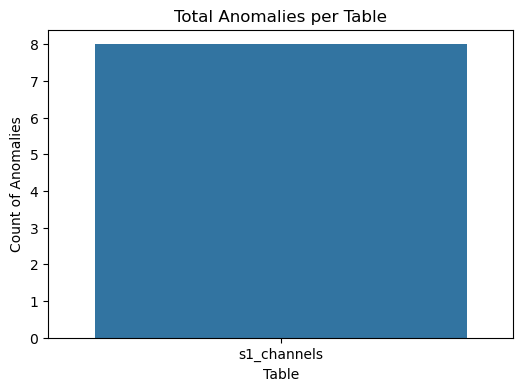

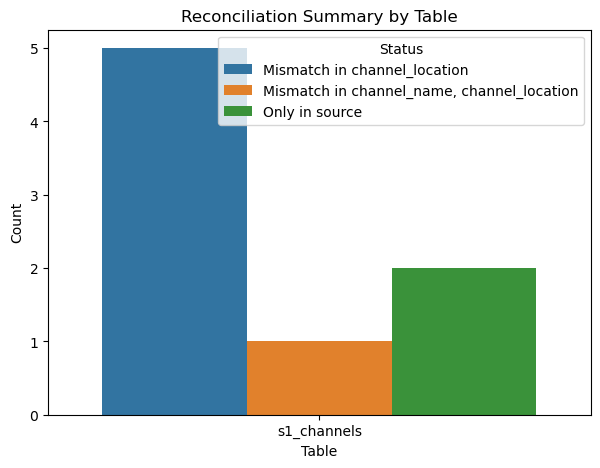

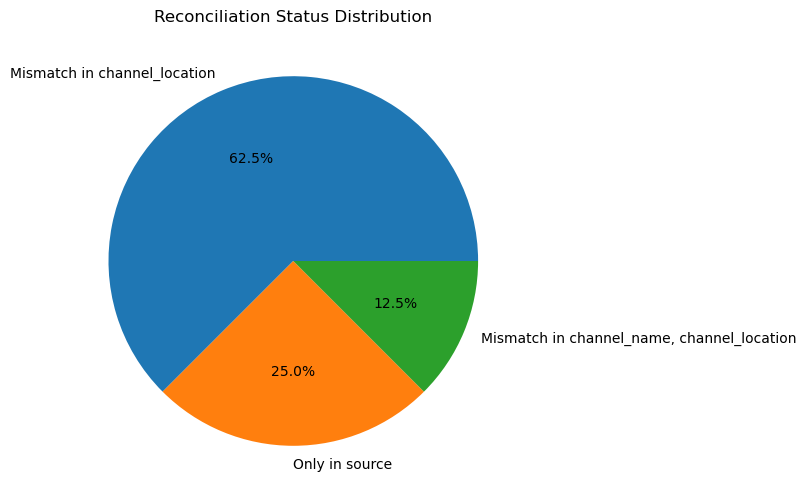

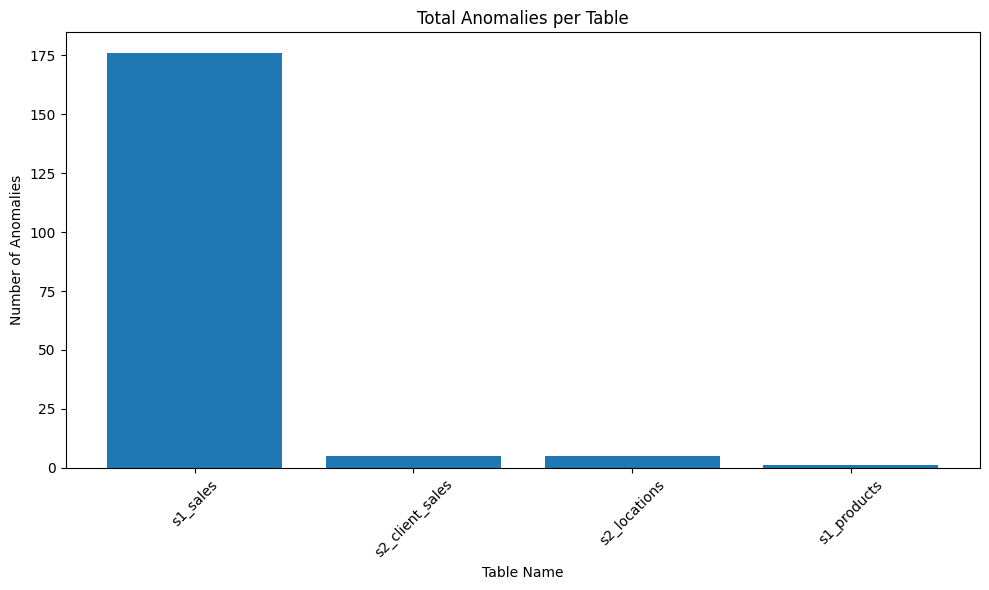

In [12]:
#Total Anomalies per Table
import matplotlib.pyplot as plt

anomalies_per_table = (
    final_reconciliation_df
    .groupby('table_name')
    .size()
    .reset_index(name='anomalies_count')
    .sort_values(by='anomalies_count', ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(anomalies_per_table['table_name'], anomalies_per_table['anomalies_count'])
plt.title('Total Anomalies per Table')
plt.xlabel('Table Name')
plt.ylabel('Number of Anomalies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

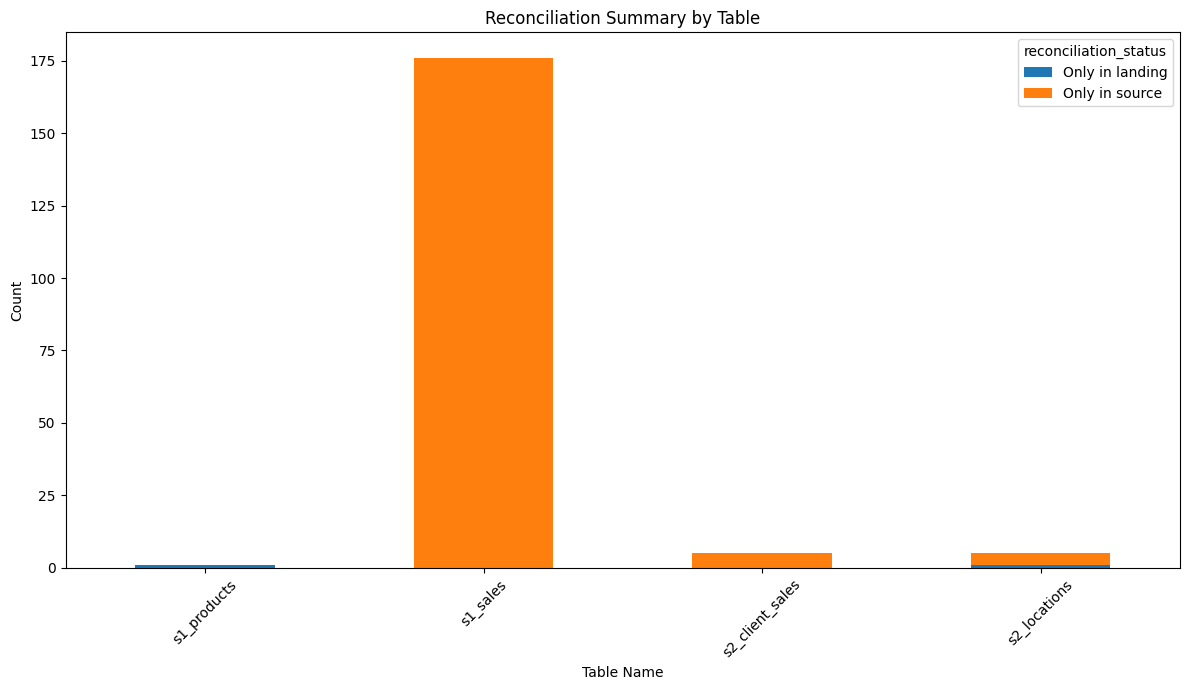

In [13]:
#Reconciliation Summary by Table
summary_by_table = (
    final_reconciliation_df
    .groupby(['table_name', 'reconciliation_status'])
    .size()
    .unstack(fill_value=0)
)

summary_by_table.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title('Reconciliation Summary by Table')
plt.xlabel('Table Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

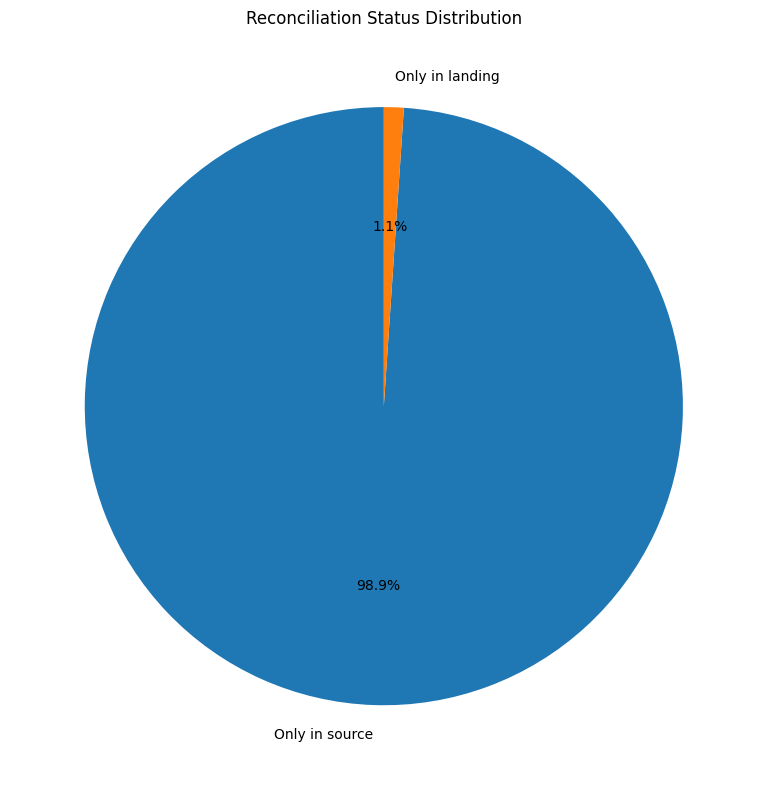

In [14]:
#Reconciliation Status Distribution
status_distribution = (
    final_reconciliation_df['reconciliation_status']
    .value_counts()
)

plt.figure(figsize=(8, 8))
plt.pie(
    status_distribution,
    labels=status_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Reconciliation Status Distribution')
plt.tight_layout()
plt.show()

In [15]:
display(anomalies_per_table)
display(summary_by_table)
display(status_distribution)

,table_name,anomalies_count
1,s1_sales,176
2,s2_client_sales,5
3,s2_locations,5
0,s1_products,1


reconciliation_status,Only in landing,Only in source
table_name,,
s1_products,1,0
s1_sales,0,176
s2_client_sales,0,5
s2_locations,1,4


reconciliation_status
Only in source     185
Only in landing      2
Name: count, dtype: int64